# ASL Recognition with CNNs

This notebook implements a Convolutional Neural Network (CNN) for recognizing American Sign Language (ASL) gestures. We will compare the performance of a Fully Connected Neural Network (FCNN) with that of a CNN on the ASL dataset.

For more information on the ASL alphabet, you can refer to this site: https://www.asl.gs/

In [10]:
import random
import torch.nn as nn
import pandas as pd
import torch
from torch.optim import Adam
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from tqdm import tqdm

In [11]:
device = torch.device("mps")

In [12]:
data_base_path = "asl_data/"

### Load data

The data for the ASL dataset is stored in CSV files. It is already split into training, validation, and test sets. Each row in the CSV files contains pixel values for a 28x28 image (flattened into a single row) and a label indicating the ASL gesture.

The labels are integers from 0 to 23, corresponding to the letters A-Z (J and Z are excluded because they require movement).

The images are grayscale, so each pixel value ranges from 0 to 255.

In [13]:
train_df = pd.read_csv(data_base_path + "train.csv")
val_df = pd.read_csv(data_base_path + "val.csv")
test_df = pd.read_csv(data_base_path + "test.csv")

In [14]:
def label_to_letter(lbl):
    letter_code = ord('A') + int(lbl)
    return chr(letter_code) if letter_code < ord('J') else chr(letter_code + 1)

def show(img, lbl):
    i = img.reshape(28,28)
    plt.figure(figsize=(5,5))
    plt.title(label_to_letter(lbl), fontdict={'fontsize': 30})
    plt.axis('off')
    plt.imshow(i, cmap='gray')

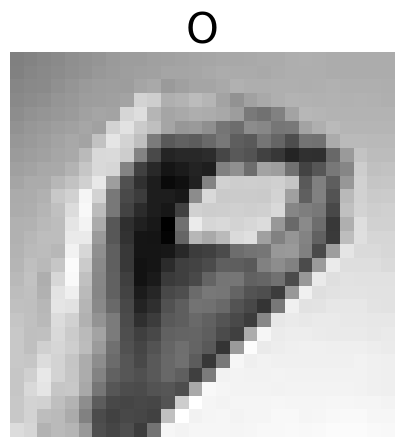

In [15]:
rnd_idx = random.choice(train_df.index)
image = train_df.iloc[rnd_idx].drop('label').values
label = train_df.iloc[rnd_idx]['label']
show(image, label)

## Preparing dataset

Let's start by creating the custom Dataset class for our ASL data. This class will take a DataFrame as input and will return the image and label for each sample. We will also normalize the pixel values to be between 0 and 1. The images will be reshaped as a 28x28 tensor with a single channel (grayscale).

In [16]:
IMG_HEIGHT = 28
IMG_WIDTH = 28
IMG_CHANNELS = 1

class AslDataset(Dataset):
    def __init__(self, base_df):
        x_df = base_df.copy()
        y_df = x_df.pop('label')
        x_df = x_df.values / 255
        x_df = x_df.reshape(-1, IMG_CHANNELS, IMG_WIDTH, IMG_HEIGHT)
        self.xs = torch.tensor(x_df).float().to(device)
        self.ys = torch.tensor(y_df).long().to(device)

    def __getitem__(self, idx):
        x = self.xs[idx]
        y = self.ys[idx]
        return x, y

    def __len__(self):
        return len(self.xs)

In [17]:
train_data = AslDataset(train_df)
val_data = AslDataset(val_df)
test_data = AslDataset(test_df)

In [18]:
batch_size = 32

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=True)

## Training functions

Now we can define our training functions. Since we will use accuracy to evaluate our model, we will create a function to calculate accuracy as well. 

In [19]:
def get_batch_accuracy(output, y, N):
    pred = output.argmax(dim=1, keepdim=True)
    correct = pred.eq(y.view_as(pred)).sum().item()
    return correct / N

Our train function performs the full training loop. For each epoch, it computes the training loss and accuracy, and then evaluates the model on the validation set. It returns the history of training and validation losses and accuracies for plotting later.

In [20]:
def train(_model, _train_loader, _val_loader, _criterion, _optimizer, _num_epochs):
    res = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': [],
    }
    iterator = tqdm(range(epochs), desc="Training", unit="epoch")

    for _ in iterator:
        _model.train()
        train_loss = 0.0
        train_acc = 0.0
        for X_batch, y_batch in _train_loader:
            _optimizer.zero_grad()
            outputs = _model(X_batch)
            loss = _criterion(outputs, y_batch)
            loss.backward()
            _optimizer.step()
            train_loss += loss.item() * X_batch.size(0)
            train_acc += get_batch_accuracy(outputs, y_batch, len(_train_loader.dataset))

        epoch_train_loss = train_loss / len(_train_loader.dataset)

        _model.eval()
        val_loss = 0.0
        val_acc = 0.0
        with torch.no_grad():
            for X_val, y_val in _val_loader:
                val_outputs = _model(X_val)
                val_loss += _criterion(val_outputs, y_val).item() * X_val.size(0)
                val_acc += get_batch_accuracy(val_outputs, y_val, len(_val_loader.dataset))

        epoch_val_loss = val_loss / len(_val_loader.dataset)

        iterator.set_postfix(
            train_loss=f"{epoch_train_loss:.4f}",
            train_acc=f"{train_acc:.4f}",
            val_loss=f"{epoch_val_loss:.4f}",
            val_acc=f"{val_acc:.4f}",
        )

        res['train_loss'].append(epoch_train_loss)
        res['train_acc'].append(train_acc)
        res['val_loss'].append(epoch_val_loss)
        res['val_acc'].append(val_acc)

    return res

This test function will evaluate the model on the test set after training is complete. It will calculate the average loss and accuracy across the entire test set.

In [21]:
def test(_model, _test_loader, _loss_function):
    _model.eval()
    test_loss = 0.0
    test_acc = 0.0
    with torch.no_grad():
        for x, y in _test_loader:
            output = _model(x)
            test_loss += _loss_function(output, y).item() * x.size(0)
            test_acc += get_batch_accuracy(output, y, len(_test_loader.dataset))

    return (test_loss / len(_test_loader.dataset)), test_acc

## Training the models

### Baseline model - fully connected network

Before we implement the CNN, let's train a simple fully connected neural network (FCNN) as a baseline. This will help us understand the performance improvement that the CNN architecture provides for image data.

In [22]:
model_fcnn = nn.Sequential(
    nn.Flatten(),
    nn.Linear(IMG_HEIGHT * IMG_WIDTH, 512),
    nn.ReLU(),
    nn.Dropout(.3),

    nn.Linear(512, 512),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_fcnn = model_fcnn.to(device)

In [23]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_fcnn.parameters())

fcnn_res = train(model_fcnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:11<00:00,  3.58s/epoch, train_acc=0.8741, train_loss=0.3652, val_acc=0.7214, val_loss=0.9136]


In [24]:
fcnn_test_loss, fcnn_test_acc = test(model_fcnn, test_loader, loss_function)

### CNN model

Now let's implement a simple CNN architecture. We will use three convolutional layers followed by max pooling, and then a couple of fully connected layers before the output layer.

In [25]:
model_cnn = nn.Sequential(
    nn.Conv2d(IMG_CHANNELS, 25, 3, stride=1, padding=1),  # 25 x 28 x 28
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 25 x 14 x 14

    nn.Conv2d(25, 50, 3, stride=1, padding=1),  # 50 x 14 x 14
    nn.ReLU(),
    nn.Dropout(.2),
    nn.MaxPool2d(2, stride=2),  # 50 x 7 x 7

    nn.Conv2d(50, 75, 3, stride=1, padding=1),  # 75 x 7 x 7
    nn.ReLU(),
    nn.MaxPool2d(2, stride=2),  # 75 x 3 x 3

    nn.Flatten(),
    nn.Linear(75 * 3 * 3, 512),
    nn.Dropout(.3),
    nn.ReLU(),
    nn.Linear(512, 24)
)

model_cnn = model_cnn.to(device)

In [26]:
epochs = 20
loss_function = nn.CrossEntropyLoss()
optimizer = Adam(model_cnn.parameters())

cnn_res = train(model_cnn, train_loader, val_loader, loss_function, optimizer, epochs)

Training: 100%|██████████| 20/20 [01:46<00:00,  5.33s/epoch, train_acc=0.9977, train_loss=0.0064, val_acc=0.9506, val_loss=0.2644]


In [27]:
cnn_test_loss, cnn_test_acc = test(model_cnn, test_loader, loss_function)

## Reflection section

### Which model is better at classifying ASL images?

El modelo de CNN obtuvo mejor estadisticas a la hora de entrenar el modelo, obteniendo un train_acc=0.9977, train_loss=0.0064, val_acc=0.9506, val_loss=0.2644 mientras que el FCNN obtuvo train_acc=0.8741, train_loss=0.3652, val_acc=0.7214, val_loss=0.9136, siendo una diferencia significativa ya que el CNN acertaria el 95% de las veces mientras que el FCNN solo un 72% con el dataset de validacion

### Which model was _faster_ to train?

El modelo de FCNN fue mas rapido de entrenar tomando 1 minuto y 13 segundos mientras que el CNN tomo 1 minuto y 46 segundos, aunque en este caso no fue mucha la diferencia, en un caso mas complejo la diferencia seria mas notable. 

### Plot and compare the learning curves of both models. What do you observe about their training and validation performance over epochs?

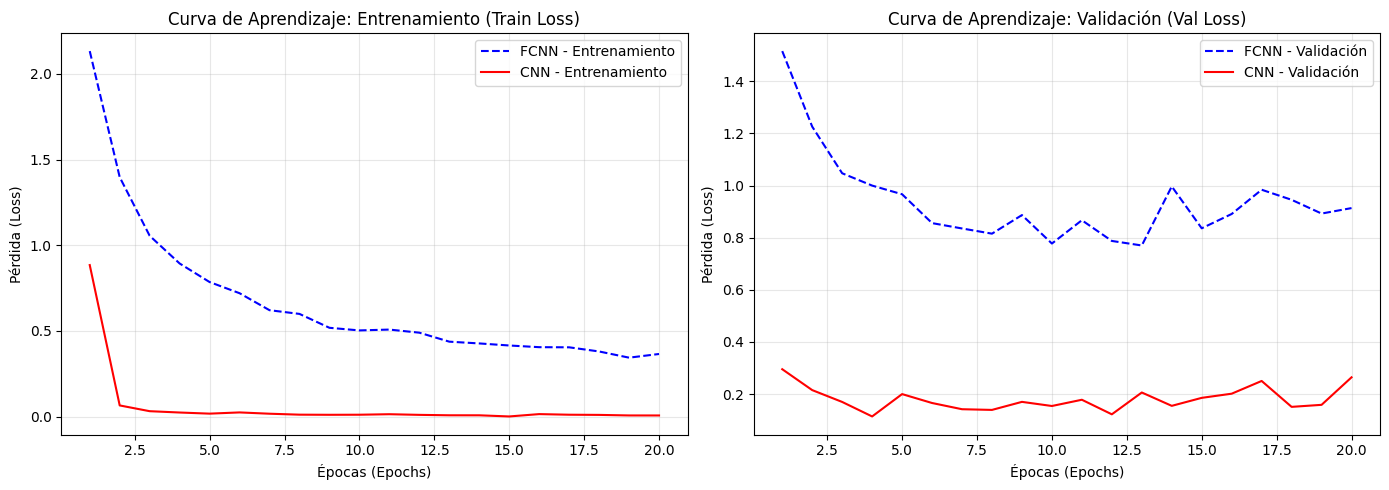

In [ ]:
import matplotlib.pyplot as plt
epochs_range = range(1, 21) 

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, fcnn_res['train_loss'], label='FCNN - Entrenamiento', color='blue', linestyle='--')
plt.plot(epochs_range, cnn_res['train_loss'], label='CNN - Entrenamiento', color='red', linestyle='-')
plt.title('Curva de Aprendizaje: Entrenamiento (Train Loss)')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, fcnn_res['val_loss'], label='FCNN - Validación', color='blue', linestyle='--')
plt.plot(epochs_range, cnn_res['val_loss'], label='CNN - Validación', color='red', linestyle='-')
plt.title('Curva de Aprendizaje: Validación (Val Loss)')
plt.xlabel('Épocas (Epochs)')
plt.ylabel('Pérdida (Loss)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

En este caso el CNN llego a estabilizarse en menos epoca, y ademas llego a un mejor resultado. mientras que el FCNN seguia bajando con la misma cantidad epoca y obtuvo una mayor perdidad.

### How many trainable parameters does each model have?

Remember that each convolutional layer has $K \times (C_{in} \times k_h \times k_w + 1)$ parameters, where $K$ is the number of filters, $C_{in}$ is the number of input channels, $k_h$ and $k_w$ are the kernel height and width, and the +1 accounts for the bias term.

Each fully connected layer has $N_{in} \times N_{out} + N_{out}$ parameters, where $N_{in}$ is the number of input features and $N_{out}$ is the number of output features.

CNN: 403,799 parametros.

FCNN:676,888 parametros.

### How do the models compare in terms of overfitting? Why do you think that is the case?

En este caso el modelo de FCNN obtuvo resultado muy separados en entrenamiento y validacion, mostrando un posible caso de overfitting. Mientras que el de CNN tiene resultados parecido ambos en entrenamiento y validacion, aunque el de validacion es un poco menos estables se encuentran en el mismo rango de perdida. Esto puede ser por que FCNN cuenta con mas parametros y termina detectando patrones no deseables 

### Final conclusions and remarks

En esta practica demuestra como el CNN es superior tanto tiempo a relacion de las epocas y los resultados que obtiene a comparacion con el FCNN. Aunque el CNN tarda un poco mas a la hora de entrenar la diferencia es signficativa para el uso de reconomiento de imagenes